# Data generation -- hrc_ur10_cell (Stage 2, Scene 1)

STEP TWO: turn the validated UR10 cell into a labelled dataset for the
device-free worker **presence / coarse count / safety-zone** task.

For each sample: pick a worker count (0 / 1 / 2), drop that many rigid
dielectric bodies at legal positions (biased toward the robot so the
zone classes balance), trace the CSI, background-subtract the empty
cell, and label:
- **presence** (0/1),
- **count** (0 / 1 / 2),
- **zone** = most-severe ISO/TS 15066 ring any worker occupies
  (0 none / 1 green / 2 yellow / 3 red).

Reuses the **verified Stage-1 tracing pipeline** (Sionna 2.0.1: dipole
arrays, PathSolver with `synthetic_array=True`, `cfr(... normalize)`,
bandwidth auto-tune, checkpoint/resume). Geometry + TX/AP + zones come
from `hrc_ur10_cell.json` so it stays in sync with the scene builder.

**Run on Colab GPU.** Upload this notebook + the `hrc_ur10_cell/`
folder (2 XMLs + JSON) into `/content`, same as the validation
notebook. The first cell installs Sionna + pins numpy and auto-restarts
once -- then Run all.

Output: `hrc_ur10_cell_data_v0.npz` (csi_raw, csi_bgsub, csi_empty,
count, presence, zone, positions, split, + meta).

In [1]:
# ================================================================
# ENVIRONMENT + PACKAGES  (Colab: install Sionna + pin numpy, restart once)
# ================================================================
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False
IN_COLAB = _in_colab()

NUMPY_PIN = '2.0.2'   # avoids the Colab numpy _blas_supports_fpe conflict
if IN_COLAB:
    import importlib.util, subprocess, sys, os
    need_restart = False
    if importlib.util.find_spec('sionna') is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sionna==2.0.1'], check=True)
        need_restart = True
    import numpy as _np
    if _np.__version__ != NUMPY_PIN:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                        '--force-reinstall', f'numpy=={NUMPY_PIN}'], check=False)
        need_restart = True
    if need_restart:
        print(f'Installed Sionna + pinned numpy=={NUMPY_PIN}. RESTARTING -- then Run all again.')
        os.kill(os.getpid(), 9)
print('env ready | Colab:', IN_COLAB)

env ready | Colab: True


In [5]:
# ================================================================
# FILES + PATHS  (upload hrc_ur10_cell/ into /content on Colab)
# ================================================================
import os, json, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

if IN_COLAB:
    OUTPUT_DIR = Path('/content')
    # find hrc_ur10_cell.json wherever it was uploaded under /content
    hits = list(Path('/content').rglob('hrc_ur10_cell.json'))
    if not hits:
        raise FileNotFoundError(
            'hrc_ur10_cell.json not found under /content. Upload the 3 scene '
            'files (hrc_ur10_cell.json + the 2 XMLs). Current /content:\n '
            + '\n  '.join(sorted(p.name for p in Path('/content').iterdir())))
    SCENE_DIR = hits[0].parent
else:
    here = Path.cwd()
    cand = here / 'scenes' / 'hrc_ur10_cell'
    SCENE_DIR = cand if cand.exists() else here
    OUTPUT_DIR = here

cfg = json.loads((SCENE_DIR / 'hrc_ur10_cell.json').read_text(encoding='utf-8'))
VARIANT = 'robot'                       # 'robot' (main) or 'norobot' (coverage-ref dataset)
SCENE_XML = str(SCENE_DIR / cfg['variants'][VARIANT])
assert Path(SCENE_XML).exists(), f'{cfg["variants"][VARIANT]} missing next to the JSON in {SCENE_DIR}'
print('scene dir :', SCENE_DIR)
print('scene xml :', SCENE_XML)
print('out       :', OUTPUT_DIR)

scene dir : /content/ hrc_ur10_cell
scene xml : /content/ hrc_ur10_cell/hrc_ur10_cell_robot.xml
out       : /content


In [6]:
# --- imports (verified Stage-1 API) ---
import mitsuba as mi
import sionna.rt
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver, Camera,
                       PathSolver, SceneObject, ITURadioMaterial,
                       subcarrier_frequencies)
print('sionna.rt', sionna.rt.__version__, '| mitsuba', mi.variant())

sionna.rt 2.0.1 | mitsuba cuda_ad_mono_polarized


In [8]:
# ================================================================
# CONSTANTS  (edit N_SAMPLES / worker + human settings here)
# ================================================================
FREQ_HZ         = 3.5e9
NUM_SUBCARRIERS = 64
K_TX, M_AP      = 4, 4

N_SAMPLES   = 8000       # start; bump later if a learning curve justifies it
MAX_WORKERS = 2          # count classes: 0 / 1 / 2
RNG_SEED    = 0

# Human proxy: a rigid dielectric body. v0 = a torso-sized sphere with
# muscle-like properties (coarse approx -- refine to a cylinder later).
HUMAN_Z      = 1.0       # torso-centre height (m)
HUMAN_SCALE  = 0.30      # sphere radius (m)
MIN_SEP      = 0.7       # min separation between two workers (m)
BIAS_P       = 0.55      # P(sample a worker near the robot) -> balances zones

# zones (from the sidecar) -- distance-from-robot rings
ZC   = cfg['safety_zones']['center']
REDR = cfg['safety_zones']['red_radius']
YELR = cfg['safety_zones']['yellow_radius']

# legal worker area (rect minus object footprints), from the sidecar
WR   = cfg['worker_region']
EXCL = WR['exclusions']
print(f'N={N_SAMPLES}, up to {MAX_WORKERS} workers | zones red<={REDR} yellow<={YELR} m')

N=8000, up to 2 workers | zones red<=1.6 yellow<=2.8 m


In [9]:
# --- load scene, arrays, TX/AP (from the sidecar) ---
scene = load_scene(SCENE_XML)
scene.frequency = FREQ_HZ

scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern='dipole', polarization='V')
scene.rx_array = PlanarArray(num_rows=1, num_cols=M_AP,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern='dipole', polarization='V')

for i, tx in enumerate(cfg['suggested_tx']):
    scene.add(Transmitter(name=f'iot_{i}', position=tx['pos'], display_radius=0.1))
scene.add(Receiver(name='ap', position=cfg['suggested_ap']['pos'], display_radius=0.1))
print('TXs:', list(scene.transmitters.keys()), '| RX:', list(scene.receivers.keys()))

TXs: ['iot_0', 'iot_1', 'iot_2', 'iot_3'] | RX: ['ap']


In [10]:
# --- solver + tracer + bandwidth auto-tune (empty scene) ---
solver = PathSolver()
SOLVER_KW = dict(max_depth=5, los=True, specular_reflection=True,
                 diffuse_reflection=False, refraction=True,
                 synthetic_array=True, seed=41)

def _cfr(spacing):
    freqs = subcarrier_frequencies(NUM_SUBCARRIERS, spacing)
    paths = solver(scene=scene, **SOLVER_KW)
    h = paths.cfr(frequencies=freqs, normalize=True, normalize_delays=True, out_type='numpy')
    return np.nan_to_num(np.squeeze(h, axis=(0, 3, 4)).astype(np.complex64))  # -> [M_AP,K_TX,N]

# Sweep bandwidth on the EMPTY cell, auto-pick smallest reaching selectivity>=0.30.
CAND_MHZ = [20, 40, 60, 80, 100]; sel = {}
for bw in CAND_MHZ:
    h = _cfr(bw * 1e6 / NUM_SUBCARRIERS)
    m = np.abs(h)
    sel[bw] = float((m.std(-1) / (m.mean(-1) + 1e-12)).mean())
    print(f'{bw:4d} MHz -> freq-selectivity {sel[bw]:.3f}')
CHOSEN_MHZ = next((bw for bw in CAND_MHZ if sel[bw] >= 0.30), 80)
SUBCARRIER_SPACING = CHOSEN_MHZ * 1e6 / NUM_SUBCARRIERS
frequencies = subcarrier_frequencies(NUM_SUBCARRIERS, SUBCARRIER_SPACING)
print(f'CHOSEN bandwidth = {CHOSEN_MHZ} MHz (spacing {SUBCARRIER_SPACING/1e3:.1f} kHz)')

def trace_csi():
    paths = solver(scene=scene, **SOLVER_KW)
    h = paths.cfr(frequencies=frequencies, normalize=True, normalize_delays=True, out_type='numpy')
    return np.nan_to_num(np.squeeze(h, axis=(0, 3, 4)).astype(np.complex64))

  20 MHz -> freq-selectivity 0.272
  40 MHz -> freq-selectivity 0.307
  60 MHz -> freq-selectivity 0.310
  80 MHz -> freq-selectivity 0.310
 100 MHz -> freq-selectivity 0.310
CHOSEN bandwidth = 40 MHz (spacing 625.0 kHz)


In [11]:
# --- add the worker bodies (parked far outside until placed) ---
# Rigid dielectric ~ muscle tissue at 3.5 GHz (eps_r~48, sigma~3). If the
# custom-material API differs on your build, fall back to an ITU dielectric.
try:
    from sionna.rt import RadioMaterial
    human_mat = RadioMaterial('human-mat', relative_permittivity=48.0, conductivity=3.0)
except Exception as e:
    print('custom RadioMaterial API differs -> ITU concrete fallback:', e)
    human_mat = ITURadioMaterial(name='human-mat', itu_type='concrete', thickness=0.3)

PARK = mi.Point3f(0.0, 0.0, -50.0)      # outside the sealed room -> no RF effect
humans = []
for w in range(MAX_WORKERS):
    obj = SceneObject(fname=sionna.rt.scene.sphere, name=f'human_{w}', radio_material=human_mat)
    scene.edit(add=obj)
    obj = scene.get(f'human_{w}')
    try:
        obj.scaling = HUMAN_SCALE
    except Exception as e:
        print('scaling API differs (non-fatal):', e)
    obj.position = PARK
    humans.append(obj)
print('workers added:', [f'human_{w}' in scene.objects for w in range(MAX_WORKERS)])

# Empty-cell reference = all workers parked (identical to a count-0 sample).
for h in humans:
    h.position = PARK
csi_empty = trace_csi()
print('csi_empty shape:', csi_empty.shape)

workers added: [True, True]
csi_empty shape: (4, 4, 64)


In [12]:
# ================================================================
# PRE-SAMPLE counts + positions + labels (deterministic -> resumable)
# ================================================================
rng = np.random.default_rng(RNG_SEED)

def in_region(x, y):
    if not (WR['x_min'] <= x <= WR['x_max'] and WR['y_min'] <= y <= WR['y_max']):
        return False
    for e in EXCL:
        if e['x_min'] <= x <= e['x_max'] and e['y_min'] <= y <= e['y_max']:
            return False
    return True

def zone_of(x, y):
    d = math.hypot(x - ZC[0], y - ZC[1])
    if d <= REDR: return 3          # red (stop)
    if d <= YELR: return 2          # yellow (reduced)
    return 1                        # green (full speed)

def sample_one(rng):
    # bias toward the robot so red/yellow are represented
    for _ in range(2000):
        if rng.random() < BIAS_P:
            r = YELR * 1.3 * math.sqrt(rng.random()); th = rng.uniform(0, 2*math.pi)
            x, y = ZC[0] + r*math.cos(th), ZC[1] + r*math.sin(th)
        else:
            x = rng.uniform(WR['x_min'], WR['x_max']); y = rng.uniform(WR['y_min'], WR['y_max'])
        if in_region(x, y):
            return x, y
    return None

counts    = rng.integers(0, MAX_WORKERS + 1, size=N_SAMPLES).astype(np.int8)
positions = np.full((N_SAMPLES, MAX_WORKERS, 2), np.nan, np.float32)
for i in range(N_SAMPLES):
    placed = []
    for _w in range(int(counts[i])):
        for _try in range(50):
            p = sample_one(rng)
            if p and all(math.hypot(p[0]-q[0], p[1]-q[1]) >= MIN_SEP for q in placed):
                placed.append(p); break
    counts[i] = len(placed)                      # in case a placement failed
    for w, (x, y) in enumerate(placed):
        positions[i, w] = (x, y)

presence = (counts > 0).astype(np.int8)
zone = np.zeros(N_SAMPLES, np.int8)              # 0 = none (no worker)
for i in range(N_SAMPLES):
    zs = [zone_of(*positions[i, w]) for w in range(int(counts[i]))]
    zone[i] = max(zs) if zs else 0

print('count  balance:', np.bincount(counts, minlength=3).tolist())
print('zone   balance (none/green/yellow/red):', np.bincount(zone, minlength=4).tolist())

count  balance: [2656, 2689, 2655]
zone   balance (none/green/yellow/red): [2656, 2970, 1383, 991]


In [13]:
# --- timing calibration: project the full-sweep runtime before committing ---
N_CALIB = 20
_t = time.time()
for i in range(N_CALIB):
    for w in range(MAX_WORKERS):
        if w < counts[i]:
            humans[w].position = mi.Point3f(float(positions[i, w, 0]), float(positions[i, w, 1]), HUMAN_Z)
        else:
            humans[w].position = PARK
    trace_csi()
per = (time.time() - _t) / N_CALIB
print(f'{per*1000:6.1f} ms / solve  ->  projected {per*N_SAMPLES/60:5.1f} min for N={N_SAMPLES:,}')

 353.7 ms / solve  ->  projected  47.2 min for N=8,000


In [14]:
# ================================================================
# SWEEP with checkpoint / resume  -> csi_raw, then background-subtract
# ================================================================
CKPT = os.path.join(OUTPUT_DIR, 'ur10_sweep_ckpt.npz')
CKPT_EVERY = 1000

if os.path.exists(CKPT):
    _z = np.load(CKPT)
    csi_raw = _z['csi_raw']; start = int(_z['done'])
    assert csi_raw.shape[0] == N_SAMPLES, 'checkpoint N mismatch -- delete ur10_sweep_ckpt.npz'
    print(f'resuming from {start:,}/{N_SAMPLES:,}')
else:
    csi_raw = np.zeros((N_SAMPLES, M_AP, K_TX, NUM_SUBCARRIERS), np.complex64); start = 0
    print('starting fresh sweep')

_t0 = time.time()
for i in range(start, N_SAMPLES):
    for w in range(MAX_WORKERS):
        if w < counts[i]:
            humans[w].position = mi.Point3f(float(positions[i, w, 0]), float(positions[i, w, 1]), HUMAN_Z)
        else:
            humans[w].position = PARK
    csi_raw[i] = trace_csi()
    if (i + 1) % CKPT_EVERY == 0 or (i + 1) == N_SAMPLES:
        np.savez(CKPT, csi_raw=csi_raw, done=i + 1)
        rate = (i + 1 - start) / (time.time() - _t0)
        print(f'  {i+1:>7,}/{N_SAMPLES:,}  ({rate:5.1f}/s, ETA {(N_SAMPLES-(i+1))/rate/60:5.1f} min)')

csi_bgsub = (csi_raw - csi_empty[None]).astype(np.complex64)
print('csi_raw:', csi_raw.shape, '| csi_bgsub:', csi_bgsub.shape, '| NaNs:', int(np.isnan(csi_raw).sum()))

starting fresh sweep
    1,000/8,000  (  6.0/s, ETA  19.5 min)
    2,000/8,000  (  6.0/s, ETA  16.5 min)
    3,000/8,000  (  6.1/s, ETA  13.7 min)
    4,000/8,000  (  6.1/s, ETA  10.9 min)
    5,000/8,000  (  6.1/s, ETA   8.2 min)
    6,000/8,000  (  6.1/s, ETA   5.4 min)
    7,000/8,000  (  6.1/s, ETA   2.7 min)
    8,000/8,000  (  6.1/s, ETA   0.0 min)
csi_raw: (8000, 4, 4, 64) | csi_bgsub: (8000, 4, 4, 64) | NaNs: 0


In [15]:
# --- split: stratified random by count (single-scene feasibility) ---
# NOTE: this is the CORE result split (can the model sense in this cell?).
# The harder cross-position / cross-scene generalisation is the Stage-2
# STRETCH and uses a spatial / cross-scene split instead. Positions are
# stored, so we can re-split later without regenerating.
split = np.empty(N_SAMPLES, dtype=object)
rs = np.random.default_rng(RNG_SEED + 1)
for c in range(MAX_WORKERS + 1):
    idx = np.where(counts == c)[0]; rs.shuffle(idx)
    n_test = int(0.15 * len(idx)); n_val = int(0.15 * len(idx))
    split[idx[:n_test]] = 'test'
    split[idx[n_test:n_test + n_val]] = 'val'
    split[idx[n_test + n_val:]] = 'train'
for s in ['train', 'val', 'test']:
    print(f'{s:5s}: {int((split == s).sum())}')

train: 5602
val  : 1199
test : 1199


In [16]:
# --- save dataset ---
out = os.path.join(OUTPUT_DIR, f'hrc_ur10_cell_data_v0_{VARIANT}.npz')
np.savez_compressed(
    out,
    csi_raw=csi_raw, csi_bgsub=csi_bgsub, csi_empty=csi_empty,
    count=counts, presence=presence, zone=zone, positions=positions,
    split=split.astype(str),
    freq_hz=FREQ_HZ, num_subcarriers=NUM_SUBCARRIERS,
    subcarrier_spacing_hz=SUBCARRIER_SPACING, k_tx=K_TX, m_ap=M_AP,
    human_z=HUMAN_Z, human_scale=HUMAN_SCALE, variant=VARIANT,
    zone_center=np.array(ZC, np.float32), red_radius=REDR, yellow_radius=YELR,
    zone_labels=np.array(['none', 'green', 'yellow', 'red']))
print('saved', out, round(os.path.getsize(out) / 1e6, 2), 'MB')
if os.path.exists(CKPT):
    os.remove(CKPT); print('removed checkpoint')

saved /content/hrc_ur10_cell_data_v0_robot.npz 110.75 MB
removed checkpoint


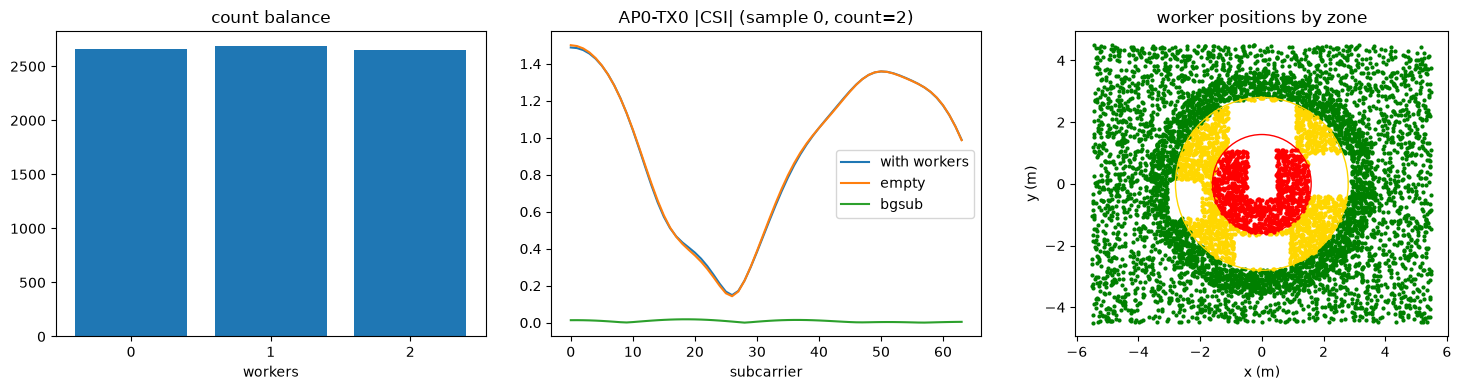

In [17]:
# --- sanity: class balance, an example bgsub, worker positions by zone ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(['0', '1', '2'], np.bincount(counts, minlength=3)); ax[0].set_title('count balance')
ax[0].set_xlabel('workers')

i = int(np.argmax(counts))     # a busy sample
ax[1].plot(np.abs(csi_raw[i, 0, 0]), label='with workers')
ax[1].plot(np.abs(csi_empty[0, 0]), label='empty')
ax[1].plot(np.abs(csi_bgsub[i, 0, 0]), label='bgsub')
ax[1].set_title(f'AP0-TX0 |CSI| (sample {i}, count={counts[i]})'); ax[1].legend(); ax[1].set_xlabel('subcarrier')

colz = {1: 'green', 2: 'gold', 3: 'red'}
for w in range(MAX_WORKERS):
    pxy = positions[:, w, :]
    m = ~np.isnan(pxy[:, 0])
    zz = np.array([zone_of(*pxy[k]) for k in np.where(m)[0]])
    for zval, col in colz.items():
        sel = zz == zval
        ax[2].scatter(pxy[m][sel, 0], pxy[m][sel, 1], s=4, c=col)
ax[2].add_patch(plt.Circle(ZC, REDR, fill=False, ec='red')); ax[2].add_patch(plt.Circle(ZC, YELR, fill=False, ec='gold'))
ax[2].set_aspect('equal'); ax[2].set_title('worker positions by zone'); ax[2].set_xlabel('x (m)'); ax[2].set_ylabel('y (m)')
fig.tight_layout(); plt.show()

## What to check

- **Bandwidth** auto-picked (expect ~80 MHz, like Stage 1).
- **Class balance:** counts roughly 1/3 each; zone has a decent share of
  yellow + red (the robot-bias sampling is what buys this). If red is
  too thin, raise `BIAS_P` or shrink the sampling disc.
- **NaNs: 0**, and the bgsub curve is clearly non-zero for busy samples
  (the workers perturb the channel) but ~0 for count-0 samples.
- **Position scatter** fills the legal area, denser near the robot.

Then **step three: the multi-task model** -- reuse the ~400k tiny-ResNet
backbone, swap the (x,y) head for three heads (presence / count / zone),
train, and report accuracy vs majority-class floors + the robot-vs-
norobot coverage comparison.